# Modeling — Logistic Regression

**Name:** Jason Justice  
**Date:** June 16, 2026  

This notebook fits a logistic regression model to predict whether an individual earns more than $50,000/year
using the cleaned UCI Adult Census Income dataset. Logistic regression is implemented as a binomial GLM
(statsmodels) for inferential analysis and as a scikit-learn Pipeline for prediction and metric computation.

**Prerequisites:** Run `01_data_prep.ipynb` first to generate `data/adult_sanitized.csv`.

---

## AI Use Disclosure

Claude Sonnet 4.6 was used to assist in drafting the structure of this notebook.


In [ ]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# Seed numpy for reproducible results
np.random.seed(2026)

# Apply a consistent plot theme
sns.set(font_scale=1.1, style="whitegrid")
%matplotlib inline

In [96]:
# Load the cleaned dataset produced by 01_data_prep.ipynb
df = pd.read_csv("data/adult_sanitized.csv")

# Encode the binary target: 1 = income >$50K, 0 = income <=50K
df["income_gt50k"] = (df["income"] == ">50K").astype(int)

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nClass distribution (income_gt50k):")
print(df["income_gt50k"].value_counts(normalize=True).round(3).to_string())
df.head()

Loaded: 30,139 rows x 16 columns

Class distribution (income_gt50k):
income_gt50k
0    0.751
1    0.249


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,income_gt50k
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


## Preprocessing

- **Drop `fnlwgt`:** a census sampling weight unrelated to individual attributes.
- **Drop `education`:** redundant with `education_num` (ordinal encoding of the same variable); retaining only `education_num` avoids collinearity.
- **Drop `income`:** the original string column is replaced by the binary `income_gt50k` target.
- **Dummy-encode** all remaining categorical features with `drop_first=True` to avoid the dummy-variable trap in the GLM design matrix.

In [ ]:
# Drop fnlwgt (sampling weight), education (redundant with education_num),
# and the raw income string
df_model = df.drop(columns=["fnlwgt", "education", "income"])

# Separate target before encoding to prevent data leakage
y = df_model.pop("income_gt50k")

# num_cols feed both models directly; cat_cols are C()-encoded in statsmodels
# and dummy-encoded for sklearn
num_cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
cat_cols = df_model.select_dtypes(include="object").columns.tolist()

# Dummy-encode categoricals for the sklearn pipeline (drop_first avoids collinearity)
X = pd.get_dummies(df_model, columns=cat_cols, drop_first=True).astype(float)

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"Categorical features encoded: {cat_cols}")

Feature matrix: 30,139 rows x 80 columns
Categorical features encoded: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


In [98]:
# 70/30 stratified split preserves the class ratio in both partitions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Train >50K rate: {y_train.mean():.3f}  |  Test >50K rate:  {y_test.mean():.3f}")

Train: 21,097 rows  |  Test: 9,042 rows
Train >50K rate: 0.249  |  Test >50K rate:  0.249


## Statsmodels — GLM Binomial (Inferential Analysis)

Logistic regression is fit using `statsmodels` `smf.glm` with `family=Binomial()`, implementing the model as a
binomial Generalized Linear Model with a logit link estimated via maximum likelihood. The formula API handles
categorical encoding internally via patsy's `C()` notation. This produces the full inferential summary:
coefficients (log-odds), standard errors, Wald z-statistics, p-values, and 95% confidence intervals.

> **Note:** The statsmodels model is fit on the **unscaled** training rows (original string categoricals) so
> that exponentiated coefficients remain directly interpretable as odds ratios. No class weighting is applied.

In [99]:
# Fit on the original string columns; patsy's C() handles categorical encoding
df_train_sm = df.loc[y_train.index].copy()

# Build the formula: numeric terms plus C() for each categorical
formula_terms = num_cols + [f"C({c})" for c in cat_cols]
formula = "income_gt50k ~ " + " + ".join(formula_terms)

# Fit the binomial GLM (logit link) via maximum likelihood
glm_result = smf.glm(formula, data=df_train_sm, family=sm.families.Binomial()).fit()

In [100]:
# Exponentiate the log-odds coefficients and CI bounds to get odds ratios
odds_ratios = np.exp(glm_result.params).rename("Odds Ratio")
conf_int = np.exp(glm_result.conf_int()).rename(
    columns={0: "CI Lower (2.5%)", 1: "CI Upper (97.5%)"}
)
p_values = glm_result.pvalues.rename("p-value")

odds_table = pd.concat([odds_ratios, conf_int, p_values], axis=1).round(4)

print("Odds Ratios with 95% Confidence Intervals (sorted by Odds Ratio):\n")
print(odds_table.sort_values("Odds Ratio", ascending=False).to_string())

Odds Ratios with 95% Confidence Intervals (sorted by Odds Ratio):

                                                 Odds Ratio  CI Lower (2.5%)  CI Upper (97.5%)  p-value
C(marital_status)[T.Married-AF-spouse]              11.9543           2.6407           54.1172   0.0013
C(marital_status)[T.Married-civ-spouse]              7.8675           4.0228           15.3867   0.0000
C(relationship)[T.Wife]                              3.8749           3.0209            4.9705   0.0000
C(sex)[T.Male]                                       2.5514           2.1079            3.0882   0.0000
C(native_country)[T.Italy]                           2.1123           0.4322           10.3242   0.3557
C(native_country)[T.Yugoslavia]                      2.0553           0.2292           18.4300   0.5198
C(occupation)[T.Exec-managerial]                     2.0400           1.7012            2.4463   0.0000
C(race)[T.Asian-Pac-Islander]                        2.0239           1.0340            3.9616   0.03

## Odds Ratio Plot (Top 20 Predictors)

The 20 predictors with the largest deviation from OR = 1.0 (no effect), with 95% confidence intervals.
Bars to the right of the dashed line (OR > 1) increase the odds of earning >$50K; bars to the left decrease them.

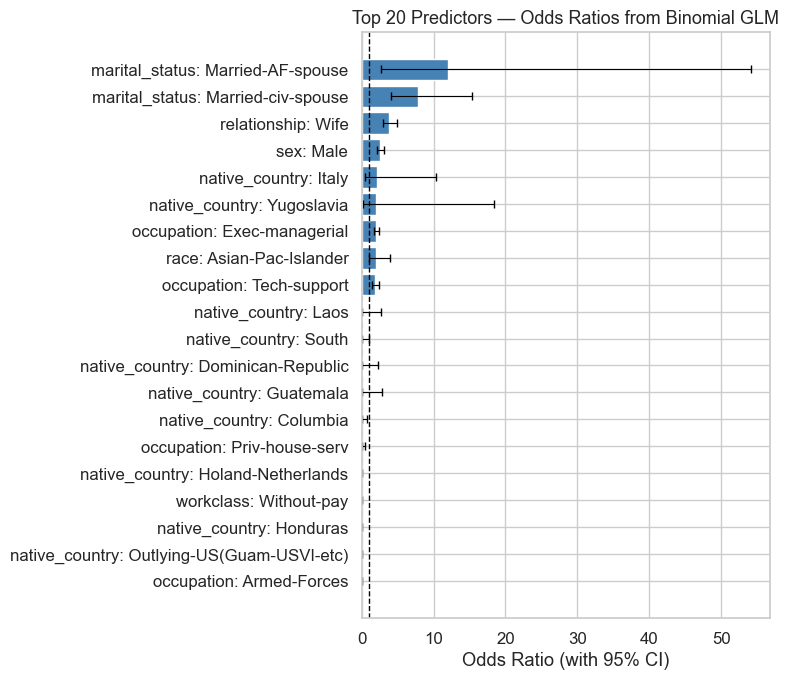

In [ ]:
import re

# Select the 20 predictors with the largest deviation from OR = 1.0
# (excluding the intercept)
plot_df = (
    odds_table.drop(index="Intercept", errors="ignore")
    .assign(abs_effect=lambda d: (d["Odds Ratio"] - 1).abs())
    .nlargest(20, "abs_effect")
    .sort_values("Odds Ratio")
)


def _clean_label(label):
    m = re.match(r"C\((\w+)\)\[T\.(.+)\]", label)
    if m:
        return f"{m.group(1)}: {m.group(2)}"
    return label


plot_df.index = [_clean_label(i) for i in plot_df.index]

figure_03, axis_03 = plt.subplots(figsize=(8, 7))
colors = ["salmon" if v < 1 else "steelblue" for v in plot_df["Odds Ratio"]]
axis_03.barh(plot_df.index, plot_df["Odds Ratio"], color=colors, edgecolor="white")
axis_03.errorbar(
    plot_df["Odds Ratio"],
    range(len(plot_df)),
    xerr=[
        plot_df["Odds Ratio"] - plot_df["CI Lower (2.5%)"],
        plot_df["CI Upper (97.5%)"] - plot_df["Odds Ratio"],
    ],
    fmt="none",
    color="black",
    capsize=3,
    linewidth=0.8,
)
axis_03.axvline(x=1, color="black", linestyle="--", linewidth=1)
axis_03.set_xlabel("Odds Ratio (with 95% CI)")
axis_03.set_title("Top 20 Predictors — Odds Ratios from Binomial GLM", fontsize=13)
plt.tight_layout()
plt.show()

## scikit-learn — Logistic Regression Pipeline (Prediction & Metrics)

The same logistic regression is fit using scikit-learn inside a `Pipeline` that first applies `StandardScaler`
(zero mean, unit variance normalization). `class_weight='balanced'` compensates for the 75/25 class imbalance
by up-weighting the minority (>$50K) class during training, improving recall on the harder-to-predict class.

In [102]:
# Pipeline: standardize features, then fit logistic regression.
# class_weight='balanced' up-weights the minority (>50K) class to offset the imbalance.
pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                solver="liblinear",
                random_state=42,
            ),
        ),
    ]
)

pipe.fit(X_train, y_train)
print("Pipeline fitted successfully.")
print(pipe)

Pipeline fitted successfully.
Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])


In [103]:
# Predict classes and positive-class probabilities on the held-out test set
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[
    :, 1
]  # column 1 = probability of the positive class (>50K)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auroc = roc_auc_score(y_test, y_prob)

# Specificity is not provided by sklearn, derive it from the matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall (Sensitivity)",
            "Specificity",
            "F1 Score",
            "AUROC",
        ],
        "Value": [accuracy, precision, recall, specificity, f1, auroc],
    }
).set_index("Metric")

print("Classification Metrics — Test Set:\n")
print(metrics_df.round(4).to_string())
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

Classification Metrics — Test Set:

                       Value
Metric                      
Accuracy              0.8102
Precision             0.5831
Recall (Sensitivity)  0.8348
Specificity           0.8021
F1 Score              0.6866
AUROC                 0.9020

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      6790
        >50K       0.58      0.83      0.69      2252

    accuracy                           0.81      9042
   macro avg       0.76      0.82      0.78      9042
weighted avg       0.85      0.81      0.82      9042



## Confusion Matrix

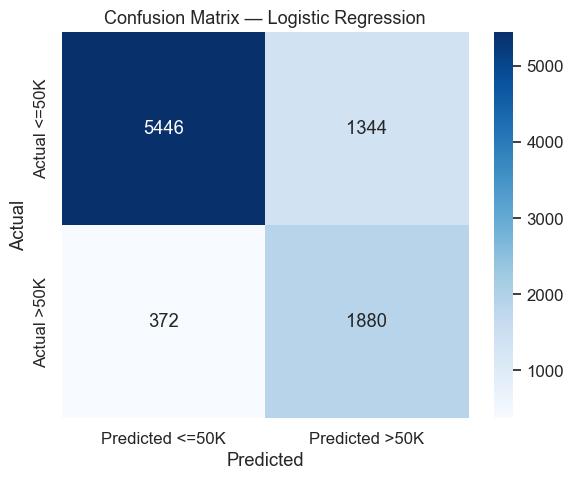

In [104]:
# Confusion matrix heatmap of actual vs. predicted classes
cm = confusion_matrix(y_test, y_pred)

figure_01, axis_01 = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted <=50K", "Predicted >50K"],
    yticklabels=["Actual <=50K", "Actual >50K"],
    ax=axis_01,
)
axis_01.set_title("Confusion Matrix — Logistic Regression", fontsize=13)
axis_01.set_ylabel("Actual")
axis_01.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

## ROC Curve

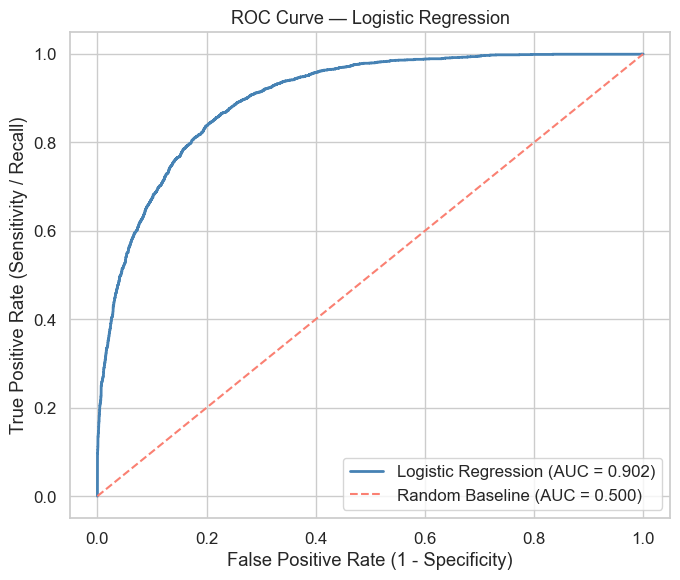

In [105]:
# ROC curve with the random-baseline diagonal for reference
fpr, tpr, _ = roc_curve(y_test, y_prob)

figure_02, axis_02 = plt.subplots(figsize=(7, 6))
axis_02.plot(
    fpr,
    tpr,
    color="steelblue",
    lw=2,
    label=f"Logistic Regression (AUC = {auroc:.3f})",
)
axis_02.plot(
    [0, 1],
    [0, 1],
    color="salmon",
    lw=1.5,
    linestyle="--",
    label="Random Baseline (AUC = 0.500)",
)
axis_02.set_xlabel("False Positive Rate (1 - Specificity)")
axis_02.set_ylabel("True Positive Rate (Sensitivity / Recall)")
axis_02.set_title("ROC Curve — Logistic Regression", fontsize=13)
axis_02.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Predicted Probability Distribution

Histogram of the model's predicted probabilities for the test set, split by actual income class.
Well-separated distributions indicate a discriminative model. The overlap region shows where the
decision boundary (default threshold = 0.5) creates misclassifications.

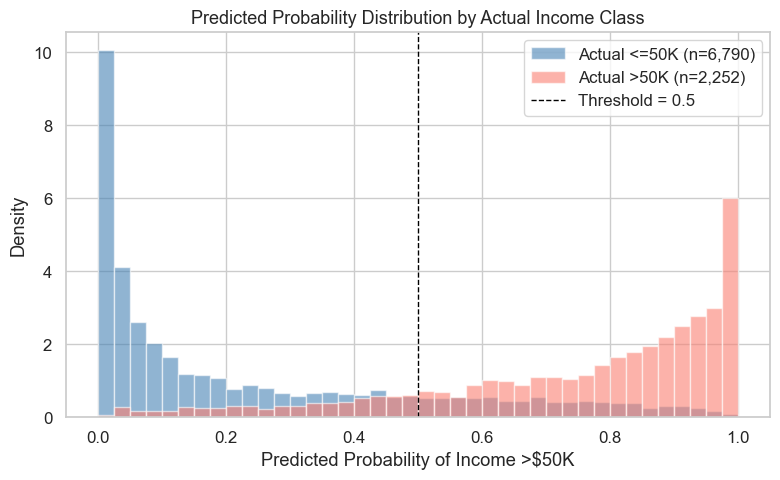

In [106]:
# Overlaid histograms of predicted probabilities, split by actual class
prob_df = pd.DataFrame({"probability": y_prob, "actual": y_test.values})

figure_04, axis_04 = plt.subplots(figsize=(8, 5))
for label, color, name in [(0, "steelblue", "<=50K"), (1, "salmon", ">50K")]:
    subset = prob_df.loc[prob_df["actual"] == label, "probability"]
    axis_04.hist(
        subset,
        bins=40,
        alpha=0.6,
        color=color,
        label=f"Actual {name} (n={len(subset):,})",
        density=True,
    )
axis_04.axvline(
    x=0.5, color="black", linestyle="--", linewidth=1, label="Threshold = 0.5"
)
axis_04.set_xlabel("Predicted Probability of Income >$50K")
axis_04.set_ylabel("Density")
axis_04.set_title(
    "Predicted Probability Distribution by Actual Income Class", fontsize=13
)
axis_04.legend()
plt.tight_layout()
plt.show()

## Conclusions and Recommendations

### Model Performance

The logistic regression model achieves strong discriminative ability (**AUROC = 0.902**), well above the 0.5
random baseline, confirming that the selected features reliably separate the two income classes. With
`class_weight='balanced'`, the model attains **recall (sensitivity) = 0.835** on the minority (>$50K) class at
**specificity = 0.802** and **accuracy = 0.810**. Precision on the >$50K class is lower (0.583), reflecting the
deliberate tradeoff of the balanced weighting: by prioritizing the detection of high earners, the model accepts
more false positives. This is an appropriate tradeoff given that false negatives carry practical consequence in
income-based eligibility decisions.

### Statistical Findings (Statsmodels GLM)

The inferential GLM summary confirms and quantifies findings from EDA:

- **Education (`education_num`)** is among the strongest continuous predictors (OR ≈ 1.34, p < 0.001): each
  additional year of education multiplies the odds of earning >$50K by roughly one third, consistent with the
  4.6× rate difference between doctoral and high-school graduates observed in EDA.
- **Age** shows a positive, significant odds ratio (OR ≈ 1.03 per year, p < 0.001), consistent with the
  mid-career income peak (ages 45–54) identified in EDA.
- **Occupation** levels for executive/managerial (`C(occupation)[T.Exec-managerial]`, OR ≈ 2.04) and
  professional specialty (OR ≈ 1.72) carry large positive odds ratios, while farming-fishing (OR ≈ 0.28) and
  private-household service roles fall well below 1.0 — reinforcing the structural inequality documented in EDA.
- **Sex (`C(sex)[T.Male]`)** carries a significant positive odds ratio (OR ≈ 2.55, p < 0.001), quantifying the
  19 percentage-point gender gap noted in EDA.
- **Capital gain** is highly significant (p < 0.001), consistent with EDA showing it as a strong differentiator
  for the >$50K group.
- **Marital status (`C(marital_status)[T.Married-civ-spouse]`)** is the strongest predictor among common
  categories (OR ≈ 7.87, p < 0.001), reflecting the combined household income effect documented in EDA.

Nearly all key predictors are statistically significant (Wald p < 0.001), and the model satisfies the
linearity-in-log-odds assumption validated in EDA for education, age, and hours per week.

### Limitations

- **Sparse-category separation:** Several rare `native_country` levels (e.g., Holand-Netherlands, Honduras,
  Outlying-US) exhibit unstable estimates — odds ratios collapsing toward 0 or diverging toward infinity with
  p-values near 1.0. This is **quasi-complete separation**, a known artifact when a category has too few
  observations to estimate reliably. It does not affect the dominant predictors (education, occupation, marital
  status, sex, capital gain), but these specific country coefficients should not be interpreted.
- **No threshold tuning:** Metrics use the default 0.5 decision threshold. Adjusting the threshold could trade
  precision against recall depending on the business objective, but this was kept fixed for simplicity.
- **Linear decision boundary:** Logistic regression assumes linearity in the log-odds; genuinely non-linear
  feature interactions are not captured and would require a more flexible model.

### Recommendations

1. **Use AUROC, recall, and specificity** as primary evaluation metrics — the 75/25 class imbalance makes raw
   accuracy (0.810) a misleading benchmark when viewed alone.
2. **Education and occupation are actionable levers:** workforce development programs targeting post-secondary
   completion and career transitions into professional roles align directly with the model's strongest predictors.
3. **The model is interpretable by design:** logistic regression coefficients expressed as odds ratios with
   Wald p-values provide a transparent audit trail suitable for policy and business decision-making.